# 05 — Method 1: Hazard × Vulnerability Decision Support

Notebook ini menjalankan **Metode 1** sebagai final decision-support layer.

**Pertanyaan utama:**

> Saat skenario risiko banjir meningkat, actor-region mana yang harus diprioritaskan untuk intervensi rantai pasok beras?

Notebook 05 menggabungkan tiga hasil:

1. **Flood hazard** dari Notebook 03.
2. **Rice vulnerability** dari Notebook 03, yang targetnya berasal dari Method 3.
3. **Stress survival** dari Notebook 04 / Method 5.

## Domain basis

Metode ini mengikuti logika disaster risk:

```text
Risk = interaction of hazard, exposure, vulnerability, and capacity
```

Karena kedua dataset tidak punya key lokasi/waktu yang sama, integrasi dilakukan sebagai **scenario-based decision support**, bukan observasi kausal atau prediksi lokasi aktual.

## References used in the methodological notes

- UNDRR / UNISDR terminology: disaster risk emerges from the interaction of hazards with exposure, vulnerability, and capacity.
- IPCC risk framing: risk is shaped by hazard, exposure, and vulnerability.
- Ponomarov & Holcomb (2009): supply chain resilience.
- Wieland & Durach (2021): supply chain resilience as capacity to persist, adapt, or transform.

In [39]:
from pathlib import Path
import json, warnings, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 180)
pd.set_option('display.width', 180)

PROJECT_ROOT = Path.cwd()
OUTPUT_DIR = PROJECT_ROOT / 'outputs'
FIG_DIR = PROJECT_ROOT / 'figures'
for p in [OUTPUT_DIR, FIG_DIR]:
    p.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 130,
    'savefig.dpi': 180,
    'font.size': 10,
    'axes.titlesize': 13,
    'axes.labelsize': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.22,
    'legend.frameon': False
})
COLORS = {
    'blue': '#2F80ED',
    'navy': '#243B53',
    'orange': '#F2994A',
    'red': '#D64545',
    'green': '#27AE60',
    'purple': '#7B61FF',
    'gray': '#6B7280',
    'teal': '#2D9CDB'
}

def savefig(name):
    path = FIG_DIR / name
    plt.tight_layout()
    plt.savefig(path, bbox_inches='tight')
    print('saved:', path)

def mode_or_unknown(s):
    s = s.dropna()
    if s.empty:
        return 'Unknown'
    return s.value_counts().idxmax()

## 1. Load outputs from Notebook 03 and Notebook 04

In [40]:
required = [
    '03_actor_region_model_summary.csv',
    '03_flood_scenario_summary.csv',
    '04_actor_region_stress_summary.csv',
    '04_stress_scenarios.csv'
]
missing = [f for f in required if not (OUTPUT_DIR / f).exists()]
if missing:
    raise FileNotFoundError(f'Jalankan Notebook 03 dan 04 dulu. Missing: {missing}')

actor_region = pd.read_csv(OUTPUT_DIR / '03_actor_region_model_summary.csv')
flood_scenarios = pd.read_csv(OUTPUT_DIR / '04_stress_scenarios.csv')
stress_summary = pd.read_csv(OUTPUT_DIR / '04_actor_region_stress_summary.csv')

def normalize_region_key(x):
    x = str(x).upper().strip()
    x = x.replace('KABUPATEN ', '').replace('KOTA ', '')
    return ' '.join(x.split())

actor_region['region_key'] = actor_region.get('region_key', actor_region['region'].map(normalize_region_key))
actor_region['region_key'] = actor_region['region_key'].map(normalize_region_key)
stress_summary['region_key'] = stress_summary.get('region_key', stress_summary['region'].map(normalize_region_key))
stress_summary['region_key'] = stress_summary['region_key'].map(normalize_region_key)

print('Actor-region:', actor_region.shape)
print('Flood scenarios:', flood_scenarios.shape)
print('Stress summary:', stress_summary.shape)
display(actor_region.head(3))
display(flood_scenarios)
display(stress_summary.head(3))

# Optional Open Data Jabar regional flood exposure bridge from Notebook 01.
# Merge uses region_key to avoid uppercase/title-case mismatch.
external_path = OUTPUT_DIR / '01b_jabar_flood_exposure_by_region.csv'
if external_path.exists():
    jabar_exposure = pd.read_csv(external_path)
    if 'region_key' not in jabar_exposure.columns:
        jabar_exposure['region_key'] = jabar_exposure['region'].map(normalize_region_key)
    jabar_exposure['region_key'] = jabar_exposure['region_key'].map(normalize_region_key)
    keep = [c for c in [
        'region_key', 'historical_flood_exposure_score', 'historical_flood_exposure_level',
        'flood_events_total', 'flood_events_recent_5y', 'external_data_coverage', 'source_file_used'
    ] if c in jabar_exposure.columns]
    jabar_exposure = jabar_exposure[keep].drop_duplicates('region_key').copy()
else:
    jabar_exposure = pd.DataFrame({
        'region_key': actor_region['region_key'].dropna().unique(),
        'historical_flood_exposure_score': 0.0,
        'historical_flood_exposure_level': 'Low',
        'external_data_coverage': 'missing'
    })

context_cols = [c for c in jabar_exposure.columns if c != 'region_key']
actor_region = actor_region.drop(columns=[c for c in context_cols if c in actor_region.columns], errors='ignore')
actor_region = actor_region.merge(jabar_exposure, on='region_key', how='left')
actor_region['historical_flood_exposure_score'] = pd.to_numeric(actor_region.get('historical_flood_exposure_score', 0), errors='coerce').fillna(0).clip(0, 1)
actor_region['historical_flood_exposure_level'] = actor_region.get('historical_flood_exposure_level', pd.Series(index=actor_region.index)).fillna('Low')
actor_region['external_data_coverage'] = actor_region.get('external_data_coverage', pd.Series(index=actor_region.index)).fillna('missing')
print('External regional flood exposure merged into decision-support input.')
print('Max exposure score:', actor_region['historical_flood_exposure_score'].max())
print(actor_region[['region', 'region_key', 'historical_flood_exposure_score']].drop_duplicates().sort_values('region_key').to_string(index=False))

Actor-region: (24, 25)
Flood scenarios: (3, 7)
Stress summary: (72, 15)


,region,actor,n_units,median_total_cost,median_revenue,median_margin,median_cost_revenue_ratio,median_operational_burden_ratio,median_margin_ratio,median_vulnerability_score,dominant_true_vulnerability_label,dominant_predicted_vulnerability_label,predicted_high_vulnerability_share,true_high_vulnerability_share,median_predicted_proba_high,region_key,flood_events_total,flood_events_mean_annual,flood_events_recent_5y,flood_events_max_yearly,flood_events_trend_slope,historical_flood_exposure_score,historical_flood_exposure_level,external_data_coverage,source_file_used
0,Garut,Farmer,98,7641100.0,13570000.0,6111000.0,0.417240,0.224878,0.582760,0.251364,Low Vulnerability,Low Vulnerability,0.204082,0.214286,0.003007,GARUT,141,10.071429,55,21,0.318681,0.394955,Medium,multi-year,jabar_flood_events_by_kabupaten_kota.csv
1,Garut,Middlemen,24,40650000.0,26840000.0,-6500000.0,1.357774,0.278229,-0.357774,0.705973,High Vulnerability,High Vulnerability,0.916667,0.916667,0.997186,GARUT,141,10.071429,55,21,0.318681,0.394955,Medium,multi-year,jabar_flood_events_by_kabupaten_kota.csv
2,Garut,Retail,23,5750000.0,3500000.0,-2600000.0,1.742857,1.000000,-0.742857,0.763876,High Vulnerability,High Vulnerability,0.913043,0.913043,1.000000,GARUT,141,10.071429,55,21,0.318681,0.394955,Medium,multi-year,jabar_flood_events_by_kabupaten_kota.csv


,flood_scenario,cost_shock_pct,scenario_interpretation,n_flood_cases,flood_probability_reference,flood_probability_min,flood_probability_max
0,Low,0.05,low cost-side stress grid,16667,0.450002,0.285010,0.475001
1,Medium,0.15,medium cost-side stress grid,16666,0.500000,0.475001,0.519999
2,High,0.30,high cost-side stress grid,16667,0.549998,0.519999,0.724990


,flood_scenario,region,region_key,actor,n_units,fail_share,survive_share,median_stressed_margin,median_stressed_cost_revenue_ratio,median_combined_buffer,dominant_stress_risk_label,dominant_predicted_vulnerability_label,median_historical_flood_exposure_score,median_effective_cost_shock_pct,stress_priority_signal
0,High,Garut,GARUT,Farmer,98,0.306122,0.693878,4.892188e+06,0.547356,0.582760,Survives Scenario,Low Vulnerability,0.394955,0.311849,Watch
1,High,Garut,GARUT,Middlemen,24,1.000000,0.000000,-2.526618e+07,1.781194,-0.357774,Already Failed,High Vulnerability,0.394955,0.311849,Severe
2,High,Garut,GARUT,Retail,23,1.000000,0.000000,-4.448485e+06,2.286365,-0.742857,Already Failed,High Vulnerability,0.394955,0.311849,Severe


External regional flood exposure merged into decision-support input.
Max exposure score: 1.0
     region  region_key  historical_flood_exposure_score
      Garut       GARUT                         0.394955
  Indramayu   INDRAMAYU                         0.055935
   Karawang    KARAWANG                         1.000000
     Subang      SUBANG                         0.364147
Tasikmalaya TASIKMALAYA                         0.006557


## External bridge policy for Method 1

Open Data Jabar historical flood events are used as a **regional exposure tie-breaker**, not as the dominant decision driver.

The core decision is still built from:

```text
predicted flood scenario + predicted rice vulnerability + Method 5 stress fail share
```

External historical exposure only modifies the final sorting score by up to 10%:

```text
priority_sort_score = base_priority_sort_score × (1 + 0.10 × historical_flood_exposure_score)
```

This preserves the primary role of the two main datasets while adding a credible regional bridge.

## 2. Decision policy

Output final menggunakan **rule-based priority matrix**, bukan supervised model baru.

Alasan:

- `priority_label` adalah hasil keputusan dari `hazard × vulnerability × stress`, bukan ground-truth observasi.
- Jika dilatih sebagai supervised target baru, model hanya akan meniru rule yang kita buat sendiri.
- Rule matrix lebih transparan untuk stakeholder kebijakan.

## Label logic

| Condition | Priority |
|---|---|
| High flood + High vulnerability | Critical |
| High/Medium flood + high stress fail share | Critical |
| High flood + Medium vulnerability | High |
| Medium flood + High vulnerability | High |
| Low flood + High vulnerability | Watchlist |
| Low vulnerability + low stress | Routine |

In [41]:
vulnerability_rank = {
    'Low Vulnerability': 1,
    'Medium Vulnerability': 2,
    'High Vulnerability': 3
}
flood_rank = {
    'Low': 1,
    'Medium': 2,
    'High': 3
}

# Use actor-region vulnerability summary from Notebook 03.
base = actor_region.copy()
base['vulnerability_label'] = base['dominant_predicted_vulnerability_label']
base['vulnerability_rank'] = base['vulnerability_label'].map(vulnerability_rank).fillna(2).astype(int)
base['region_key'] = base['region_key'].map(normalize_region_key)
stress_summary['region_key'] = stress_summary['region_key'].map(normalize_region_key)

# Merge stress result by scenario + actor + region_key.
base_cols = [
    'region_key', 'region', 'actor', 'n_units',
    'vulnerability_label', 'vulnerability_rank',
    'predicted_high_vulnerability_share',
    'median_cost_revenue_ratio',
    'median_margin',
    'historical_flood_exposure_score',
    'historical_flood_exposure_level',
    'external_data_coverage',
] + ([c for c in ['median_vulnerability_score', 'median_predicted_proba_high'] if c in base.columns])

base_for_merge = base[[c for c in base_cols if c in base.columns]].rename(columns={'region': 'model_region'})
decision = stress_summary.merge(
    base_for_merge,
    on=['region_key', 'actor'],
    how='left',
    suffixes=('', '_from_model')
)
if 'model_region' in decision.columns:
    decision['region'] = decision['region'].fillna(decision['model_region'])
    decision = decision.drop(columns=['model_region'])

# Add flood scenario probability reference.
decision = decision.merge(
    flood_scenarios[['flood_scenario', 'flood_probability_reference', 'cost_shock_pct']],
    on='flood_scenario',
    how='left',
    suffixes=('', '_scenario')
)
decision['flood_rank'] = decision['flood_scenario'].map(flood_rank).fillna(2).astype(int)

def assign_priority(row):
    flood = row['flood_rank']
    vuln = row['vulnerability_rank']
    fail_share = row['fail_share']

    if flood == 3 and vuln == 3:
        return 'Critical'
    if flood >= 2 and fail_share >= 0.75:
        return 'Critical'
    if flood == 3 and fail_share >= 0.50:
        return 'Critical'
    if flood == 3 and vuln == 2:
        return 'High'
    if flood == 2 and vuln == 3:
        return 'High'
    if fail_share >= 0.50:
        return 'High'
    if vuln == 3:
        return 'Watchlist'
    if flood == 3 and vuln == 1:
        return 'Moderate'
    if fail_share >= 0.25:
        return 'Moderate'
    return 'Routine'

decision['priority_label'] = decision.apply(assign_priority, axis=1)

priority_rank = {'Routine': 1, 'Moderate': 2, 'Watchlist': 3, 'High': 4, 'Critical': 5}
decision['priority_rank'] = decision['priority_label'].map(priority_rank)

# Keep a score for sorting only, not as a trained target.
decision['base_priority_sort_score'] = (
    0.45 * (decision['vulnerability_rank'] / 3)
    + 0.35 * (decision['flood_rank'] / 3)
    + 0.20 * decision['fail_share'].fillna(0)
)

# Open Data Jabar regional flood exposure acts as a small tie-breaker only.
# It can increase the score by at most 10%, so it does not dominate the primary flood/rice outputs.
decision['historical_flood_exposure_score'] = pd.to_numeric(decision.get('historical_flood_exposure_score', 0), errors='coerce').fillna(0).clip(0, 1)
decision['regional_exposure_priority_modifier'] = 1 + 0.10 * decision['historical_flood_exposure_score']
decision['priority_sort_score'] = (decision['base_priority_sort_score'] * decision['regional_exposure_priority_modifier']).clip(0, 1.10)
display(decision.head())

,flood_scenario,region,region_key,actor,n_units,fail_share,survive_share,median_stressed_margin,median_stressed_cost_revenue_ratio,median_combined_buffer,dominant_stress_risk_label,dominant_predicted_vulnerability_label,median_historical_flood_exposure_score,median_effective_cost_shock_pct,stress_priority_signal,n_units_from_model,vulnerability_label,vulnerability_rank,predicted_high_vulnerability_share,median_cost_revenue_ratio,median_margin,historical_flood_exposure_score,historical_flood_exposure_level,external_data_coverage,median_vulnerability_score,median_predicted_proba_high,flood_probability_reference,cost_shock_pct,flood_rank,priority_label,priority_rank,base_priority_sort_score,regional_exposure_priority_modifier,priority_sort_score
0,High,Garut,GARUT,Farmer,98,0.306122,0.693878,4.892188e+06,0.547356,0.582760,Survives Scenario,Low Vulnerability,0.394955,0.311849,Watch,98,Low Vulnerability,1,0.204082,0.417240,6.111000e+06,0.394955,Medium,multi-year,0.251364,0.003007,0.549998,0.3,3,Moderate,2,0.561224,1.039496,0.583390
1,High,Garut,GARUT,Middlemen,24,1.000000,0.000000,-2.526618e+07,1.781194,-0.357774,Already Failed,High Vulnerability,0.394955,0.311849,Severe,24,High Vulnerability,3,0.916667,1.357774,-6.500000e+06,0.394955,Medium,multi-year,0.705973,0.997186,0.549998,0.3,3,Critical,5,1.000000,1.039496,1.039496
2,High,Garut,GARUT,Retail,23,1.000000,0.000000,-4.448485e+06,2.286365,-0.742857,Already Failed,High Vulnerability,0.394955,0.311849,Severe,23,High Vulnerability,3,0.913043,1.742857,-2.600000e+06,0.394955,Medium,multi-year,0.763876,1.000000,0.549998,0.3,3,Critical,5,1.000000,1.039496,1.039496
3,High,Garut,GARUT,Rice Miller,24,0.666667,0.333333,-5.552166e+06,1.094476,0.165699,Already Failed,Low Vulnerability,0.394955,0.311849,High,24,Low Vulnerability,1,0.416667,0.834301,1.070069e+07,0.394955,Medium,multi-year,0.290517,0.017077,0.549998,0.3,3,Critical,5,0.633333,1.039496,0.658347
4,High,Garut,GARUT,Wholesaler,25,0.920000,0.080000,-2.832875e+07,1.416200,-0.079545,Already Failed,High Vulnerability,0.394955,0.311849,Severe,25,High Vulnerability,3,0.720000,1.079545,-7.000000e+06,0.394955,Medium,multi-year,0.746619,0.968412,0.549998,0.3,3,Critical,5,0.984000,1.039496,1.022864


## 3. Recommended action per actor and priority

In [42]:
def recommended_action(row):
    actor = str(row['actor'])
    priority = row['priority_label']
    fail_share = row['fail_share']
    cr = row.get('median_cost_revenue_ratio', np.nan)

    if priority == 'Critical':
        if actor == 'Farmer':
            return 'Prioritize input-cost support, harvest protection, and post-flood production monitoring.'
        if actor == 'Rice Miller':
            return 'Secure milling capacity, backup machine schedule, and protect grain-to-rice processing continuity.'
        if actor == 'Middlemen':
            return 'Monitor distribution bottleneck, prepare alternative storage, and coordinate pickup/delivery windows.'
        if actor == 'Wholesaler':
            return 'Prepare buffer stock and route contingency for bulk distribution.'
        if actor == 'Retail':
            return 'Prepare buffer stock, backup suppliers, and consumer price monitoring.'
        return 'Immediate monitoring and continuity support.'
    if priority == 'High':
        if fail_share >= 0.50:
            return 'Prepare contingency plan because many units fail under stress scenario.'
        return 'Increase monitoring frequency and prepare targeted operational support.'
    if priority == 'Watchlist':
        return 'Watch financial feasibility and margin because vulnerability is high even when flood scenario is not high.'
    if priority == 'Moderate':
        return 'Monitor periodically and prepare support if flood-risk scenario escalates.'
    return 'Routine monitoring.'

decision['recommended_action'] = decision.apply(recommended_action, axis=1)

# Reason text.
def priority_reason(row):
    parts = [
        f"Flood={row['flood_scenario']}",
        f"Vulnerability={row['vulnerability_label']}",
        f"FailShare={row['fail_share']:.0%}"
    ]
    if pd.notna(row.get('median_cost_revenue_ratio')):
        parts.append(f"Median C/R={row['median_cost_revenue_ratio']:.2f}")
    if pd.notna(row.get('historical_flood_exposure_score')):
        parts.append(f"HistFloodExp={row['historical_flood_exposure_score']:.2f}")
    return '; '.join(parts)

decision['priority_reason'] = decision.apply(priority_reason, axis=1)

cols = [
    'region', 'actor', 'flood_scenario', 'flood_probability_reference',
    'vulnerability_label', 'predicted_high_vulnerability_share',
    'fail_share', 'survive_share',
    'dominant_stress_risk_label',
    'median_margin', 'median_cost_revenue_ratio',
    'median_stressed_margin', 'median_stressed_cost_revenue_ratio',
    'priority_label', 'priority_rank', 'base_priority_sort_score', 'historical_flood_exposure_score', 'regional_exposure_priority_modifier', 'priority_sort_score',
    'priority_reason', 'recommended_action'
]
cols = [c for c in cols if c in decision.columns]
final_priority = decision[cols].sort_values(['priority_rank', 'priority_sort_score'], ascending=[False, False]).reset_index(drop=True)

final_priority.to_csv(OUTPUT_DIR / '05_final_flood_logistics_priority.csv', index=False)
display(final_priority.head(15))

,region,actor,flood_scenario,flood_probability_reference,vulnerability_label,predicted_high_vulnerability_share,fail_share,survive_share,dominant_stress_risk_label,median_margin,median_cost_revenue_ratio,median_stressed_margin,median_stressed_cost_revenue_ratio,priority_label,priority_rank,base_priority_sort_score,historical_flood_exposure_score,regional_exposure_priority_modifier,priority_sort_score,priority_reason,recommended_action
0,Karawang,Retail,High,0.549998,High Vulnerability,1.000000,1.000000,0.000000,Already Failed,-3.070000e+06,2.023333,-5.006600e+06,2.691033,Critical,5,1.000000,1.000000,1.100000,1.100000,Flood=High; Vulnerability=High Vulnerability; ...,"Prepare buffer stock, backup suppliers, and co..."
1,Karawang,Rice Miller,High,0.549998,High Vulnerability,0.714286,1.000000,0.000000,Already Failed,-5.688835e+06,1.064403,-3.553185e+07,1.415656,Critical,5,1.000000,1.000000,1.100000,1.100000,Flood=High; Vulnerability=High Vulnerability; ...,"Secure milling capacity, backup machine schedu..."
2,Karawang,Wholesaler,High,0.549998,High Vulnerability,0.571429,0.785714,0.214286,Already Failed,-3.500000e+06,1.018028,-6.752950e+07,1.353978,Critical,5,0.957143,1.000000,1.100000,1.052857,Flood=High; Vulnerability=High Vulnerability; ...,Prepare buffer stock and route contingency for...
3,Garut,Middlemen,High,0.549998,High Vulnerability,0.916667,1.000000,0.000000,Already Failed,-6.500000e+06,1.357774,-2.526618e+07,1.781194,Critical,5,1.000000,0.394955,1.039496,1.039496,Flood=High; Vulnerability=High Vulnerability; ...,"Monitor distribution bottleneck, prepare alter..."
4,Garut,Retail,High,0.549998,High Vulnerability,0.913043,1.000000,0.000000,Already Failed,-2.600000e+06,1.742857,-4.448485e+06,2.286365,Critical,5,1.000000,0.394955,1.039496,1.039496,Flood=High; Vulnerability=High Vulnerability; ...,"Prepare buffer stock, backup suppliers, and co..."
5,Subang,Retail,High,0.549998,High Vulnerability,0.947368,1.000000,0.000000,Already Failed,-2.495000e+06,1.733333,-4.210084e+06,2.272269,Critical,5,1.000000,0.364147,1.036415,1.036415,Flood=High; Vulnerability=High Vulnerability; ...,"Prepare buffer stock, backup suppliers, and co..."
6,Garut,Wholesaler,High,0.549998,High Vulnerability,0.720000,0.920000,0.080000,Already Failed,-7.000000e+06,1.079545,-2.832875e+07,1.416200,Critical,5,0.984000,0.394955,1.039496,1.022864,Flood=High; Vulnerability=High Vulnerability; ...,Prepare buffer stock and route contingency for...
7,Subang,Middlemen,High,0.549998,High Vulnerability,0.428571,0.857143,0.142857,Already Failed,1.484000e+07,0.922399,-2.122185e+07,1.209196,Critical,5,0.971429,0.364147,1.036415,1.006803,Flood=High; Vulnerability=High Vulnerability; ...,"Monitor distribution bottleneck, prepare alter..."
8,Indramayu,Retail,High,0.549998,High Vulnerability,1.000000,1.000000,0.000000,Already Failed,-3.051000e+06,2.114500,-4.703987e+06,2.752398,Critical,5,1.000000,0.055935,1.005594,1.005594,Flood=High; Vulnerability=High Vulnerability; ...,"Prepare buffer stock, backup suppliers, and co..."
9,Tasikmalaya,Middlemen,High,0.549998,High Vulnerability,0.793103,1.000000,0.000000,Already Failed,-7.685347e+06,1.296086,-2.091446e+07,1.685167,Critical,5,1.000000,0.006557,1.000656,1.000656,Flood=High; Vulnerability=High Vulnerability; ...,"Monitor distribution bottleneck, prepare alter..."


## 4. High-priority shortlist

In [43]:
shortlist = final_priority[final_priority['priority_label'].isin(['Critical', 'High'])].copy()
shortlist.to_csv(OUTPUT_DIR / '05_high_priority_shortlist.csv', index=False)

actions = (
    final_priority.groupby(['flood_scenario', 'priority_label', 'actor'], dropna=False)
    .agg(
        n_actor_region=('actor', 'size'),
        avg_fail_share=('fail_share', 'mean'),
        example_action=('recommended_action', mode_or_unknown)
    )
    .reset_index()
    .sort_values(['flood_scenario', 'priority_label', 'avg_fail_share'], ascending=[True, True, False])
)
actions.to_csv(OUTPUT_DIR / '05_actor_region_recommended_actions.csv', index=False)

print('Critical/High rows:', len(shortlist))
display(shortlist.head(20))
display(actions.head(20))

Critical/High rows: 44


,region,actor,flood_scenario,flood_probability_reference,vulnerability_label,predicted_high_vulnerability_share,fail_share,survive_share,dominant_stress_risk_label,median_margin,median_cost_revenue_ratio,median_stressed_margin,median_stressed_cost_revenue_ratio,priority_label,priority_rank,base_priority_sort_score,historical_flood_exposure_score,regional_exposure_priority_modifier,priority_sort_score,priority_reason,recommended_action
0,Karawang,Retail,High,0.549998,High Vulnerability,1.000000,1.000000,0.000000,Already Failed,-3.070000e+06,2.023333,-5.006600e+06,2.691033,Critical,5,1.000000,1.000000,1.100000,1.100000,Flood=High; Vulnerability=High Vulnerability; ...,"Prepare buffer stock, backup suppliers, and co..."
1,Karawang,Rice Miller,High,0.549998,High Vulnerability,0.714286,1.000000,0.000000,Already Failed,-5.688835e+06,1.064403,-3.553185e+07,1.415656,Critical,5,1.000000,1.000000,1.100000,1.100000,Flood=High; Vulnerability=High Vulnerability; ...,"Secure milling capacity, backup machine schedu..."
2,Karawang,Wholesaler,High,0.549998,High Vulnerability,0.571429,0.785714,0.214286,Already Failed,-3.500000e+06,1.018028,-6.752950e+07,1.353978,Critical,5,0.957143,1.000000,1.100000,1.052857,Flood=High; Vulnerability=High Vulnerability; ...,Prepare buffer stock and route contingency for...
3,Garut,Middlemen,High,0.549998,High Vulnerability,0.916667,1.000000,0.000000,Already Failed,-6.500000e+06,1.357774,-2.526618e+07,1.781194,Critical,5,1.000000,0.394955,1.039496,1.039496,Flood=High; Vulnerability=High Vulnerability; ...,"Monitor distribution bottleneck, prepare alter..."
4,Garut,Retail,High,0.549998,High Vulnerability,0.913043,1.000000,0.000000,Already Failed,-2.600000e+06,1.742857,-4.448485e+06,2.286365,Critical,5,1.000000,0.394955,1.039496,1.039496,Flood=High; Vulnerability=High Vulnerability; ...,"Prepare buffer stock, backup suppliers, and co..."
5,Subang,Retail,High,0.549998,High Vulnerability,0.947368,1.000000,0.000000,Already Failed,-2.495000e+06,1.733333,-4.210084e+06,2.272269,Critical,5,1.000000,0.364147,1.036415,1.036415,Flood=High; Vulnerability=High Vulnerability; ...,"Prepare buffer stock, backup suppliers, and co..."
6,Garut,Wholesaler,High,0.549998,High Vulnerability,0.720000,0.920000,0.080000,Already Failed,-7.000000e+06,1.079545,-2.832875e+07,1.416200,Critical,5,0.984000,0.394955,1.039496,1.022864,Flood=High; Vulnerability=High Vulnerability; ...,Prepare buffer stock and route contingency for...
7,Subang,Middlemen,High,0.549998,High Vulnerability,0.428571,0.857143,0.142857,Already Failed,1.484000e+07,0.922399,-2.122185e+07,1.209196,Critical,5,0.971429,0.364147,1.036415,1.006803,Flood=High; Vulnerability=High Vulnerability; ...,"Monitor distribution bottleneck, prepare alter..."
8,Indramayu,Retail,High,0.549998,High Vulnerability,1.000000,1.000000,0.000000,Already Failed,-3.051000e+06,2.114500,-4.703987e+06,2.752398,Critical,5,1.000000,0.055935,1.005594,1.005594,Flood=High; Vulnerability=High Vulnerability; ...,"Prepare buffer stock, backup suppliers, and co..."
9,Tasikmalaya,Middlemen,High,0.549998,High Vulnerability,0.793103,1.000000,0.000000,Already Failed,-7.685347e+06,1.296086,-2.091446e+07,1.685167,Critical,5,1.000000,0.006557,1.000656,1.000656,Flood=High; Vulnerability=High Vulnerability; ...,"Monitor distribution bottleneck, prepare alter..."


,flood_scenario,priority_label,actor,n_actor_region,avg_fail_share,example_action
1,High,Critical,Retail,5,1.000000,"Prepare buffer stock, backup suppliers, and co..."
0,High,Critical,Middlemen,5,0.933929,"Monitor distribution bottleneck, prepare alter..."
2,High,Critical,Rice Miller,4,0.870014,"Secure milling capacity, backup machine schedu..."
3,High,Critical,Wholesaler,3,0.797738,Prepare buffer stock and route contingency for...
5,High,Moderate,Rice Miller,1,0.476190,Monitor periodically and prepare support if fl...
6,High,Moderate,Wholesaler,1,0.190476,Monitor periodically and prepare support if fl...
4,High,Moderate,Farmer,5,0.173895,Monitor periodically and prepare support if fl...
8,Low,High,Retail,5,0.991304,Prepare contingency plan because many units fa...
7,Low,High,Middlemen,4,0.810576,Prepare contingency plan because many units fa...
9,Low,High,Rice Miller,1,0.785714,Prepare contingency plan because many units fa...


## 5. Focused visualizations

saved: c:\Users\USER\Documents\VSCODE\flood_rice_resilience_project\figures\05_priority_distribution_by_scenario.png


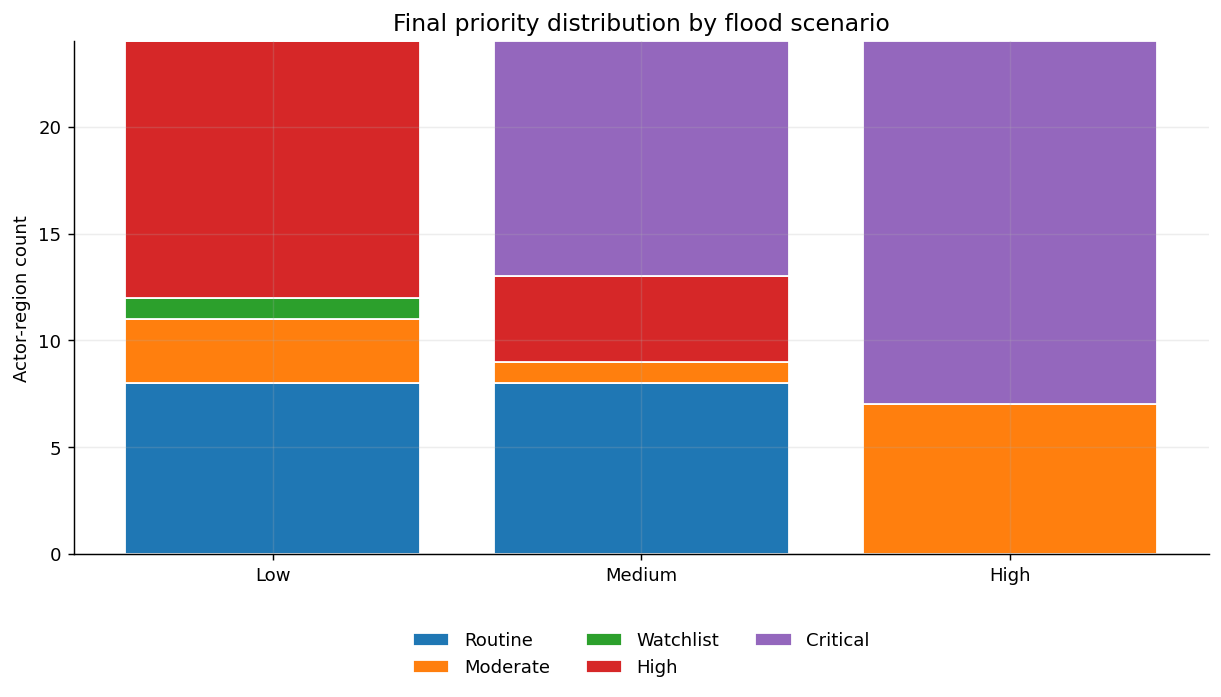

saved: c:\Users\USER\Documents\VSCODE\flood_rice_resilience_project\figures\05_top_high_flood_priorities.png


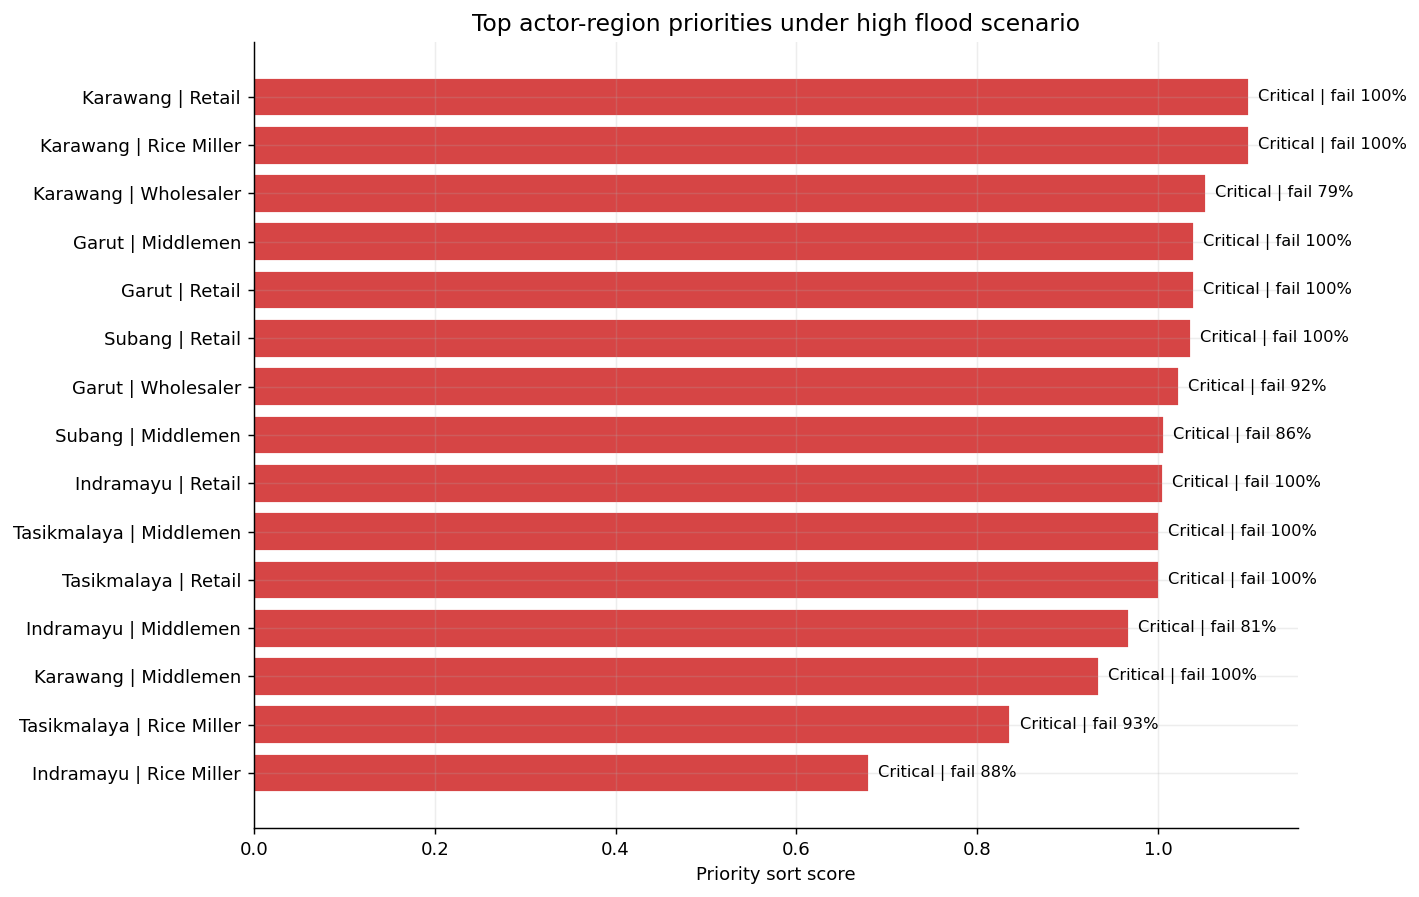

saved: c:\Users\USER\Documents\VSCODE\flood_rice_resilience_project\figures\05_high_flood_critical_high_share_by_actor.png


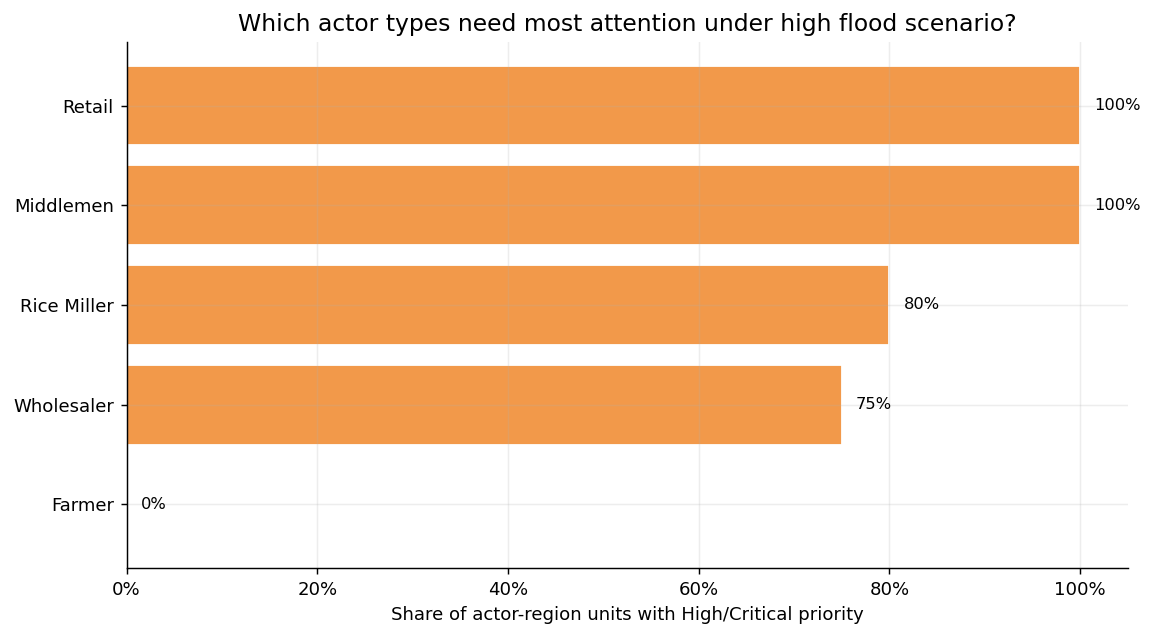

In [44]:
# Visualization 1: priority count by scenario.
priority_order = ['Routine', 'Moderate', 'Watchlist', 'High', 'Critical']
count_df = (
    final_priority.groupby(['flood_scenario', 'priority_label'])
    .size()
    .reset_index(name='count')
)
pivot = count_df.pivot(index='flood_scenario', columns='priority_label', values='count').reindex(index=['Low', 'Medium', 'High']).fillna(0)
pivot = pivot.reindex(columns=[c for c in priority_order if c in pivot.columns]).fillna(0)

fig, ax = plt.subplots(figsize=(9.5, 5.5))
bottom = np.zeros(len(pivot))
for col in pivot.columns:
    vals = pivot[col].values
    ax.bar(pivot.index, vals, bottom=bottom, label=col, edgecolor='white')
    bottom += vals
ax.set_ylabel('Actor-region count')
ax.set_title('Final priority distribution by flood scenario')
ax.legend(ncols=3, bbox_to_anchor=(0.5, -0.12), loc='upper center')
savefig('05_priority_distribution_by_scenario.png')
plt.show()

# Visualization 2: high scenario ranking.
high = final_priority[final_priority['flood_scenario'].eq('High')].copy()
top = high.sort_values(['priority_rank', 'priority_sort_score'], ascending=[False, False]).head(15)
fig, ax = plt.subplots(figsize=(11, 7))
labels = top['region'] + ' | ' + top['actor']
bars = ax.barh(labels[::-1], top['priority_sort_score'][::-1], color=COLORS['red'], edgecolor='white')
ax.set_xlabel('Priority sort score')
ax.set_title('Top actor-region priorities under high flood scenario')
for b, lab, fail in zip(bars, top['priority_label'][::-1], top['fail_share'][::-1]):
    ax.text(b.get_width() + 0.01, b.get_y() + b.get_height()/2, f'{lab} | fail {fail:.0%}', va='center', fontsize=9)
savefig('05_top_high_flood_priorities.png')
plt.show()

# Visualization 3: critical/high share by actor under high scenario.
actor_priority = (
    high.assign(_critical_high=high['priority_label'].isin(['Critical', 'High']).astype(float))
    .groupby('actor')
    .agg(critical_high_share=('_critical_high', 'mean'), n_actor_region=('actor', 'size'))
    .reset_index()
    .sort_values('critical_high_share')
)
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(actor_priority['actor'], actor_priority['critical_high_share'], color=COLORS['orange'], edgecolor='white')
ax.xaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_xlabel('Share of actor-region units with High/Critical priority')
ax.set_title('Which actor types need most attention under high flood scenario?')
for b, v in zip(bars, actor_priority['critical_high_share']):
    ax.text(v + 0.015, b.get_y() + b.get_height()/2, f'{v:.0%}', va='center', fontsize=9)
savefig('05_high_flood_critical_high_share_by_actor.png')
plt.show()

## 5B. Final decision diagnostics and stakeholder-facing summary

The final notebook should make the Method 1 decision layer transparent. The following outputs show the priority matrix, stakeholder action summary, and a presentation-ready top intervention shortlist.

saved: c:\Users\USER\Documents\VSCODE\flood_rice_resilience_project\figures\05_priority_matrix_heatmap.png


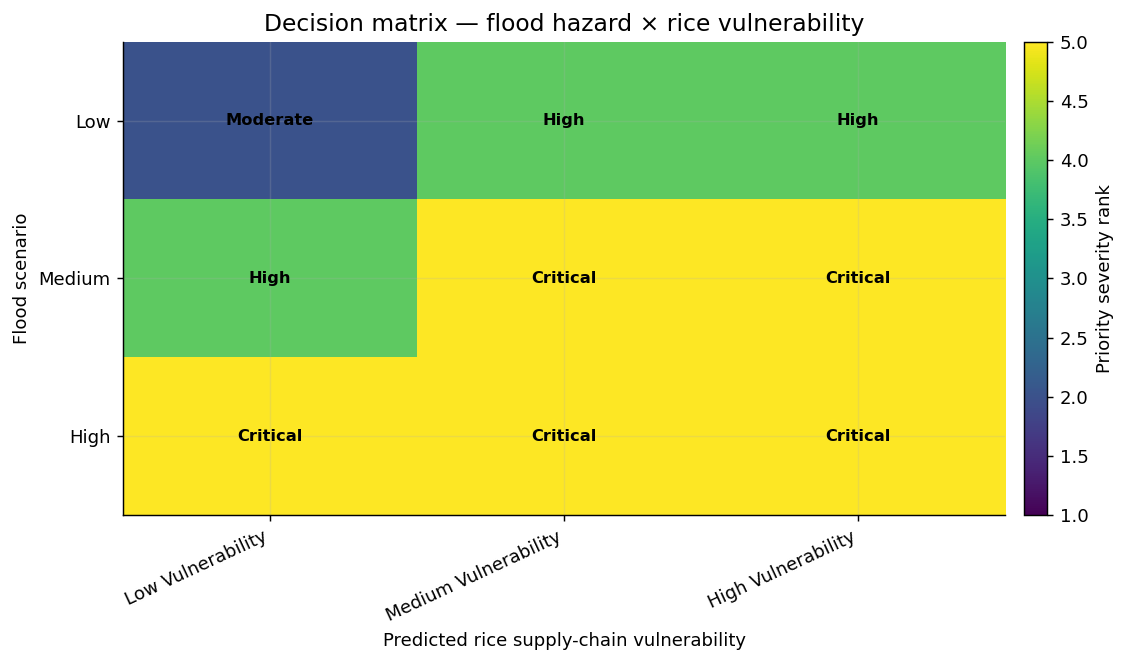

,region,actor,flood_scenario,vulnerability_label,fail_share,median_cost_revenue_ratio,median_stressed_margin,priority_label,priority_reason,recommended_action
0,Karawang,Retail,High,High Vulnerability,1.000000,2.023333,-5.006600e+06,Critical,Flood=High; Vulnerability=High Vulnerability; ...,"Prepare buffer stock, backup suppliers, and co..."
1,Karawang,Rice Miller,High,High Vulnerability,1.000000,1.064403,-3.553185e+07,Critical,Flood=High; Vulnerability=High Vulnerability; ...,"Secure milling capacity, backup machine schedu..."
2,Karawang,Wholesaler,High,High Vulnerability,0.785714,1.018028,-6.752950e+07,Critical,Flood=High; Vulnerability=High Vulnerability; ...,Prepare buffer stock and route contingency for...
4,Garut,Retail,High,High Vulnerability,1.000000,1.742857,-4.448485e+06,Critical,Flood=High; Vulnerability=High Vulnerability; ...,"Prepare buffer stock, backup suppliers, and co..."
3,Garut,Middlemen,High,High Vulnerability,1.000000,1.357774,-2.526618e+07,Critical,Flood=High; Vulnerability=High Vulnerability; ...,"Monitor distribution bottleneck, prepare alter..."
5,Subang,Retail,High,High Vulnerability,1.000000,1.733333,-4.210084e+06,Critical,Flood=High; Vulnerability=High Vulnerability; ...,"Prepare buffer stock, backup suppliers, and co..."
6,Garut,Wholesaler,High,High Vulnerability,0.920000,1.079545,-2.832875e+07,Critical,Flood=High; Vulnerability=High Vulnerability; ...,Prepare buffer stock and route contingency for...
7,Subang,Middlemen,High,High Vulnerability,0.857143,0.922399,-2.122185e+07,Critical,Flood=High; Vulnerability=High Vulnerability; ...,"Monitor distribution bottleneck, prepare alter..."
8,Indramayu,Retail,High,High Vulnerability,1.000000,2.114500,-4.703987e+06,Critical,Flood=High; Vulnerability=High Vulnerability; ...,"Prepare buffer stock, backup suppliers, and co..."
10,Tasikmalaya,Retail,High,High Vulnerability,1.000000,2.017917,-4.871066e+06,Critical,Flood=High; Vulnerability=High Vulnerability; ...,"Prepare buffer stock, backup suppliers, and co..."


,stakeholder,action_focus,trigger,specific_use
0,Dinas Ketahanan Pangan,Prioritize buffer stock and supply continuity ...,"Priority label = Critical or High, especially ...",Identify which actor-region nodes need food av...
1,BPBD / disaster coordination team,Use flood scenario as logistics alert trigger ...,High flood scenario combined with High Vulnera...,Connect disaster preparedness with food logist...
2,Bulog / Bapanas or local food reserve managers,Prepare stock redistribution and backup supply...,High fail share or High/Critical priority amon...,Target limited reserve or distribution support...
3,Dinas Perdagangan,Monitor price pressure in downstream nodes wit...,Retail or wholesaler actor-region units with H...,Focus price monitoring on areas where retailer...
4,Supply-chain actors / cooperatives,Use actor-specific recommendations to prepare ...,Actor-region appears in top intervention short...,Translate risk score into operational actions ...


In [45]:
# Priority matrix heatmap: vulnerability × flood scenario.
priority_rank = {'Routine': 1, 'Moderate': 2, 'Watchlist': 3, 'High': 4, 'Critical': 5}
priority_rank_inv = {v: k for k, v in priority_rank.items()}

matrix = (
    final_priority.groupby(['flood_scenario', 'vulnerability_label'], dropna=False)
    .agg(max_priority_rank=('priority_rank', 'max'), n_actor_region=('actor', 'size'))
    .reset_index()
)
scenario_order = ['Low', 'Medium', 'High']
vuln_order = ['Low Vulnerability', 'Medium Vulnerability', 'High Vulnerability']
mat = matrix.pivot(index='flood_scenario', columns='vulnerability_label', values='max_priority_rank').reindex(index=scenario_order, columns=vuln_order)
mat.to_csv(OUTPUT_DIR / '05_priority_matrix_heatmap_values.csv')

fig, ax = plt.subplots(figsize=(8.8, 5.2))
im = ax.imshow(mat.fillna(0).values, aspect='auto', vmin=1, vmax=5)
ax.set_xticks(range(len(mat.columns))); ax.set_xticklabels(mat.columns, rotation=25, ha='right')
ax.set_yticks(range(len(mat.index))); ax.set_yticklabels(mat.index)
ax.set_xlabel('Predicted rice supply-chain vulnerability')
ax.set_ylabel('Flood scenario')
ax.set_title('Decision matrix — flood hazard × rice vulnerability')
for i, scen in enumerate(mat.index):
    for j, vuln in enumerate(mat.columns):
        val = mat.loc[scen, vuln]
        if pd.notna(val) and val > 0:
            ax.text(j, i, priority_rank_inv.get(int(val), ''), ha='center', va='center', fontsize=9, fontweight='bold')
cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
cbar.set_label('Priority severity rank')
savefig('05_priority_matrix_heatmap.png')
plt.show()

# Final top 10 intervention priority table under high flood scenario.
top10 = (
    final_priority[final_priority['flood_scenario'].eq('High')]
    .sort_values(['priority_rank', 'priority_sort_score', 'fail_share', 'median_cost_revenue_ratio'], ascending=[False, False, False, False])
    .head(10)
    .copy()
)
top10_cols = [
    'region', 'actor', 'flood_scenario', 'vulnerability_label', 'fail_share',
    'median_cost_revenue_ratio', 'median_stressed_margin', 'priority_label',
    'priority_reason', 'recommended_action'
]
top10_cols = [c for c in top10_cols if c in top10.columns]
top10[top10_cols].to_csv(OUTPUT_DIR / '05_top10_intervention_priority.csv', index=False)
display(top10[top10_cols])

# Stakeholder-facing action summary.
stakeholder_actions = pd.DataFrame([
    {
        'stakeholder': 'Dinas Ketahanan Pangan',
        'action_focus': 'Prioritize buffer stock and supply continuity monitoring for Critical actor-region units.',
        'trigger': 'Priority label = Critical or High, especially under High flood scenario.',
        'specific_use': 'Identify which actor-region nodes need food availability monitoring before disruption escalates.'
    },
    {
        'stakeholder': 'BPBD / disaster coordination team',
        'action_focus': 'Use flood scenario as logistics alert trigger for vulnerable supply-chain nodes.',
        'trigger': 'High flood scenario combined with High Vulnerability or high fail share.',
        'specific_use': 'Connect disaster preparedness with food logistics risk rather than treating flood risk as a standalone hazard.'
    },
    {
        'stakeholder': 'Bulog / Bapanas or local food reserve managers',
        'action_focus': 'Prepare stock redistribution and backup supply for retail, wholesalers, and middlemen with Critical priority.',
        'trigger': 'High fail share or High/Critical priority among downstream actors.',
        'specific_use': 'Target limited reserve or distribution support to nodes most likely to disrupt consumer access.'
    },
    {
        'stakeholder': 'Dinas Perdagangan',
        'action_focus': 'Monitor price pressure in downstream nodes with weak margin and high cost/revenue ratio.',
        'trigger': 'Retail or wholesaler actor-region units with High Vulnerability and High/Critical priority.',
        'specific_use': 'Focus price monitoring on areas where retailer feasibility is already weak.'
    },
    {
        'stakeholder': 'Supply-chain actors / cooperatives',
        'action_focus': 'Use actor-specific recommendations to prepare backup suppliers, storage, or processing capacity.',
        'trigger': 'Actor-region appears in top intervention shortlist.',
        'specific_use': 'Translate risk score into operational actions at farmer, miller, middleman, wholesaler, and retail levels.'
    },
])
stakeholder_actions.to_csv(OUTPUT_DIR / '05_stakeholder_action_summary.csv', index=False)
display(stakeholder_actions)

## 6. Export methodological notes and decision policy

In [46]:
policy = pd.DataFrame([
    {
        'decision': 'Use hazard × vulnerability as final decision layer',
        'domain_basis': 'Disaster risk is understood through interaction of hazard, exposure, vulnerability, and capacity.',
        'reference': 'UNDRR/UNISDR terminology; IPCC risk framing'
    },
    {
        'decision': 'Do not train new supervised priority model',
        'domain_basis': 'Priority label is a decision rule output, not observed ground truth.',
        'reference': 'Model governance / pseudo-label limitation'
    },
    {
        'decision': 'Critical if high flood and high vulnerability',
        'domain_basis': 'A high hazard scenario interacting with highly vulnerable supply-chain units creates highest intervention need.',
        'reference': 'Hazard-vulnerability risk framework'
    },
    {
        'decision': 'Use Open Data Jabar flood-event counts as low-impact regional exposure tie-breaker',
        'domain_basis': 'Historical flood occurrence gives regional exposure context but does not replace primary FloodPrediction model.',
        'reference': 'Open Data Jabar / BPBD flood-event dataset; hazard-exposure-vulnerability risk framework'
    },
    {
        'decision': 'Use stress fail share as capacity/resilience signal',
        'domain_basis': 'Resilience concerns ability to persist/adapt under disruption; failure under stress indicates low buffer.',
        'reference': 'Ponomarov & Holcomb (2009); Wieland & Durach (2021)'
    },
    {
        'decision': 'Actor-specific recommended actions',
        'domain_basis': 'Different rice supply-chain actors represent different operational roles: production, milling, intermediation, wholesale, and retail access.',
        'reference': 'Rice supply chain structure from provided dataset'
    }
])
policy.to_csv(OUTPUT_DIR / '05_decision_policy_reference.csv', index=False)

notes = '''# Method 1 Notes — Hazard × Vulnerability Decision Support

This notebook is a decision-support layer, not a new supervised model.

## Why no new model?

The final priority label is not observed ground truth. It is a policy-style decision layer built from:

1. predicted flood hazard scenario,
2. predicted rice supply-chain vulnerability, and
3. stress-test survival / fail-share from Method 5.

Training another model to predict this label would only replicate the rule matrix and make the process less transparent.

## Domain grounding

The decision framework follows disaster-risk logic: risk emerges from the interaction of hazard with exposure, vulnerability, and capacity. In this project:

- flood scenario = hazard,
- rice actor-region unit = exposed supply-chain node,
- vulnerability label = financial/operational vulnerability,
- stress fail share = low resilience / low buffer,
- historical flood exposure = regional tie-breaker from Open Data Jabar,
- priority label = intervention priority.

## Limitation

Because the flood and rice datasets do not share a common geographic or temporal key, this notebook does not claim actual flood impact prediction for a specific district/date. It is a scenario-based risk-prioritization framework.
'''
(OUTPUT_DIR / '05_method1_notes.md').write_text(notes, encoding='utf-8')

manifest = {
    'final_output': '05_final_flood_logistics_priority.csv',
    'shortlist_output': '05_high_priority_shortlist.csv',
    'recommended_action_output': '05_actor_region_recommended_actions.csv',
    'scope': 'scenario-based decision support',
    'not_a_claim': 'not actual location-specific flood impact prediction',
    'input_notebooks': ['03_model_training_evaluation', '04_flood_stress_test_sensitivity_analysis'],
}
json.dump(manifest, open(OUTPUT_DIR / '05_decision_support_manifest.json', 'w'), indent=2)

print('Saved Method 1 outputs:')
for p in sorted(OUTPUT_DIR.glob('05_*')):
    print('-', p.name)

Saved Method 1 outputs:
- 05_actor_region_recommended_actions.csv
- 05_decision_policy_reference.csv
- 05_decision_support_manifest.json
- 05_final_flood_logistics_priority.csv
- 05_high_priority_shortlist.csv
- 05_method1_notes.md
- 05_monte_carlo_enhanced_priority.csv
- 05_monte_carlo_high_priority_heatmap_values.csv
- 05_monte_carlo_priority_distribution_share.csv
- 05_monte_carlo_priority_policy.csv
- 05_monte_carlo_top10_component_contribution.csv
- 05_monte_carlo_visualization_index.csv
- 05_priority_matrix_heatmap_values.csv
- 05_stakeholder_action_summary.csv
- 05_top10_intervention_priority.csv
- 05_top10_monte_carlo_priority.csv


## 7. Monte Carlo-enhanced priority layer

Notebook 04 now produces Monte Carlo failure probabilities for each actor-region-scenario. This section uses those probabilities as a probabilistic resilience component in the final priority score.

This does **not** replace the Method 1 rule-based decision matrix. It adds a second decision-support view that uses uncertainty-aware failure probability from Method 5.

The external Open Data Jabar flood-event bridge remains a small regional modifier only, weighted at 10% in this layer.

The Monte Carlo-enhanced layer keeps the original Method 1 rule-based priority intact, then adds a second uncertainty-adjusted view using Notebook 04 failure probabilities.

In [47]:
# Monte Carlo-enhanced final priority layer.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

OUTPUT_DIR = Path('outputs') if Path('outputs').exists() else Path('/mnt/data/outputs')
FIG_DIR = Path('figures') if Path('figures').exists() else Path('/mnt/data/figures')
OUTPUT_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)

def normalize_region_key(x):
    x = str(x).upper().strip()
    x = x.replace('KABUPATEN ', '').replace('KOTA ', '')
    return ' '.join(x.split())

final_priority = pd.read_csv(OUTPUT_DIR / '05_final_flood_logistics_priority.csv')
mc_summary = pd.read_csv(OUTPUT_DIR / '04_monte_carlo_actor_region_summary.csv')
external_exposure = pd.read_csv(OUTPUT_DIR / '01b_jabar_flood_exposure_by_region.csv')

final_priority['region_key'] = final_priority.get('region_key', final_priority['region'].map(normalize_region_key))
final_priority['region_key'] = final_priority['region_key'].map(normalize_region_key)
mc_summary['region_key'] = mc_summary.get('region_key', mc_summary['region'].map(normalize_region_key))
mc_summary['region_key'] = mc_summary['region_key'].map(normalize_region_key)
external_exposure['region_key'] = external_exposure.get('region_key', external_exposure['region'].map(normalize_region_key))
external_exposure['region_key'] = external_exposure['region_key'].map(normalize_region_key)

mc_cols = [
    'region_key', 'actor', 'flood_scenario',
    'mean_failure_probability', 'median_failure_probability', 'p75_failure_probability',
    'dominant_monte_carlo_risk_label', 'monte_carlo_priority_signal',
    'expected_stressed_margin', 'p05_stressed_margin', 'p50_stressed_margin', 'p95_stressed_margin'
]
mc_cols = [c for c in mc_cols if c in mc_summary.columns]
priority_mc = final_priority.merge(mc_summary[mc_cols], on=['region_key', 'actor', 'flood_scenario'], how='left')

# Robust external exposure merge.
# final_priority may already contain historical_flood_exposure_* columns from the rule-based priority layer.
# Drop them before merging the authoritative exposure table again, otherwise pandas creates _x/_y suffixes.
priority_mc = priority_mc.drop(
    columns=[c for c in ['historical_flood_exposure_score', 'historical_flood_exposure_level'] if c in priority_mc.columns],
    errors='ignore'
)

needed_exposure_cols = ['region_key', 'historical_flood_exposure_score', 'historical_flood_exposure_level']
missing_exposure_cols = [c for c in needed_exposure_cols if c not in external_exposure.columns]
if missing_exposure_cols:
    raise KeyError(
        f'External exposure file is missing columns: {missing_exposure_cols}. '
        f'Available columns: {external_exposure.columns.tolist()}. '
        'Run Notebook 01 again to regenerate outputs/01b_jabar_flood_exposure_by_region.csv.'
    )

priority_mc = priority_mc.merge(
    external_exposure[needed_exposure_cols].drop_duplicates('region_key'),
    on='region_key',
    how='left'
)
priority_mc['mean_failure_probability'] = pd.to_numeric(priority_mc['mean_failure_probability'], errors='coerce').fillna(priority_mc['fail_share']).clip(0, 1)
priority_mc['historical_flood_exposure_score'] = pd.to_numeric(
    priority_mc['historical_flood_exposure_score'], errors='coerce'
).fillna(0).clip(0, 1)
priority_mc['historical_flood_exposure_level'] = priority_mc['historical_flood_exposure_level'].fillna('Low')

# Component scores. External bridge receives only a small 10% role so it cannot dominate the primary datasets.
vulnerability_score_map = {'Low Vulnerability': 0.20, 'Medium Vulnerability': 0.60, 'High Vulnerability': 1.00}
flood_score_map = {'Low': 0.20, 'Medium': 0.55, 'High': 1.00}
priority_mc['vulnerability_component'] = priority_mc['vulnerability_label'].map(vulnerability_score_map).fillna(0.50)
priority_mc['hazard_component'] = priority_mc['flood_scenario'].map(flood_score_map).fillna(0.50)
priority_mc['monte_carlo_failure_component'] = priority_mc['mean_failure_probability']
priority_mc['external_exposure_component'] = priority_mc['historical_flood_exposure_score']

priority_mc['monte_carlo_enhanced_priority_score'] = (
    0.35 * priority_mc['vulnerability_component'] +
    0.30 * priority_mc['hazard_component'] +
    0.25 * priority_mc['monte_carlo_failure_component'] +
    0.10 * priority_mc['external_exposure_component']
)

def label_mc_priority(score):
    if score >= 0.78:
        return 'Critical'
    if score >= 0.58:
        return 'High'
    if score >= 0.35:
        return 'Moderate'
    return 'Low'

priority_mc['monte_carlo_enhanced_priority_label'] = priority_mc['monte_carlo_enhanced_priority_score'].apply(label_mc_priority)
priority_mc['monte_carlo_priority_reason'] = (
    'Vulnerability=' + priority_mc['vulnerability_label'].astype(str) +
    '; Flood=' + priority_mc['flood_scenario'].astype(str) +
    '; MC failure=' + (priority_mc['mean_failure_probability'] * 100).round(1).astype(str) + '%' +
    '; Historical exposure=' + (priority_mc['historical_flood_exposure_score'] * 100).round(1).astype(str) + '%'
)

priority_mc = priority_mc.sort_values(
    ['monte_carlo_enhanced_priority_score', 'mean_failure_probability', 'predicted_high_vulnerability_share'],
    ascending=False
).reset_index(drop=True)
priority_mc['monte_carlo_priority_rank'] = np.arange(1, len(priority_mc) + 1)

priority_mc.to_csv(OUTPUT_DIR / '05_monte_carlo_enhanced_priority.csv', index=False)
priority_mc.head(10).to_csv(OUTPUT_DIR / '05_top10_monte_carlo_priority.csv', index=False)

mc_policy = pd.DataFrame([
    {'component': 'vulnerability_component', 'weight': 0.35, 'source': 'Method 3 pseudo-label vulnerability', 'role': 'primary rice supply-chain vulnerability component'},
    {'component': 'hazard_component', 'weight': 0.30, 'source': 'Flood scenario from primary Flood Prediction model', 'role': 'primary flood hazard component'},
    {'component': 'monte_carlo_failure_component', 'weight': 0.25, 'source': 'Notebook 04 Monte Carlo failure probability', 'role': 'probabilistic resilience/failure component'},
    {'component': 'external_exposure_component', 'weight': 0.10, 'source': 'Open Data Jabar flood-event bridge', 'role': 'small regional exposure modifier only, not primary model driver'},
])
mc_policy.to_csv(OUTPUT_DIR / '05_monte_carlo_priority_policy.csv', index=False)

print('External exposure max score in MC priority:', priority_mc['historical_flood_exposure_score'].max())
display(priority_mc[['monte_carlo_priority_rank', 'region', 'actor', 'flood_scenario',
                     'vulnerability_label', 'mean_failure_probability',
                     'historical_flood_exposure_score', 'monte_carlo_enhanced_priority_label',
                     'monte_carlo_enhanced_priority_score', 'recommended_action']].head(10))

External exposure max score in MC priority: 1.0


,monte_carlo_priority_rank,region,actor,flood_scenario,vulnerability_label,mean_failure_probability,historical_flood_exposure_score,monte_carlo_enhanced_priority_label,monte_carlo_enhanced_priority_score,recommended_action
0,1,Karawang,Retail,High,High Vulnerability,1.000000,1.000000,Critical,1.000000,"Prepare buffer stock, backup suppliers, and co..."
1,2,Karawang,Rice Miller,High,High Vulnerability,1.000000,1.000000,Critical,1.000000,"Secure milling capacity, backup machine schedu..."
2,3,Karawang,Wholesaler,High,High Vulnerability,0.865071,1.000000,Critical,0.966268,Prepare buffer stock and route contingency for...
3,4,Garut,Middlemen,High,High Vulnerability,1.000000,0.394955,Critical,0.939496,"Monitor distribution bottleneck, prepare alter..."
4,5,Garut,Retail,High,High Vulnerability,1.000000,0.394955,Critical,0.939496,"Prepare buffer stock, backup suppliers, and co..."
5,6,Subang,Retail,High,High Vulnerability,1.000000,0.364147,Critical,0.936415,"Prepare buffer stock, backup suppliers, and co..."
6,7,Garut,Wholesaler,High,High Vulnerability,0.923240,0.394955,Critical,0.920306,Prepare buffer stock and route contingency for...
7,8,Subang,Middlemen,High,High Vulnerability,0.908952,0.364147,Critical,0.913653,"Monitor distribution bottleneck, prepare alter..."
8,9,Indramayu,Retail,High,High Vulnerability,1.000000,0.055935,Critical,0.905594,"Prepare buffer stock, backup suppliers, and co..."
9,10,Tasikmalaya,Retail,High,High Vulnerability,1.000000,0.006557,Critical,0.900656,"Prepare buffer stock, backup suppliers, and co..."


saved: figures\05_monte_carlo_priority_distribution.png


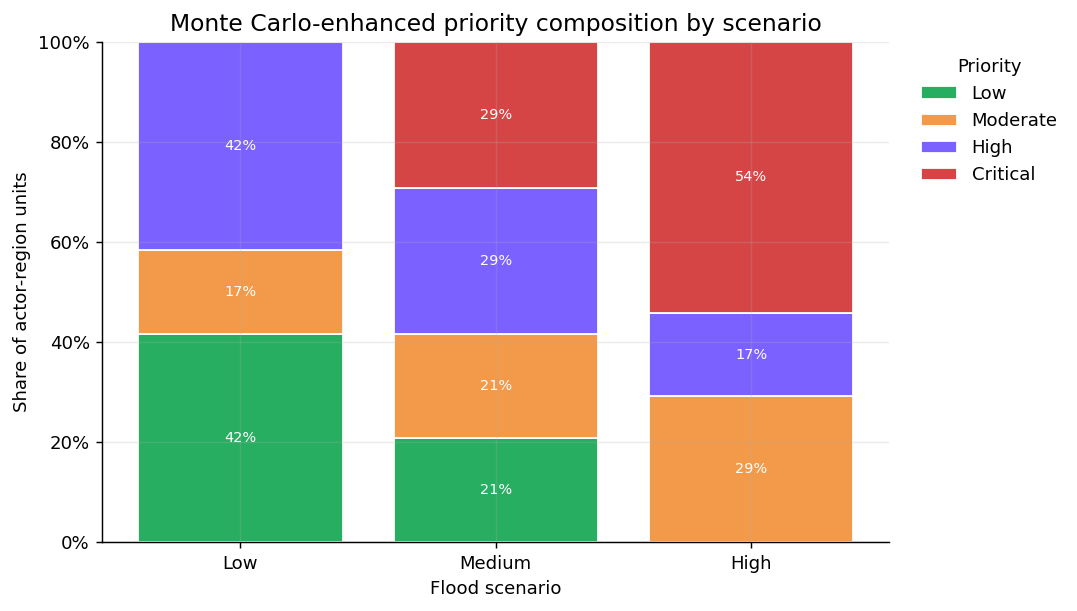

saved: figures\05_monte_carlo_high_priority_heatmap.png


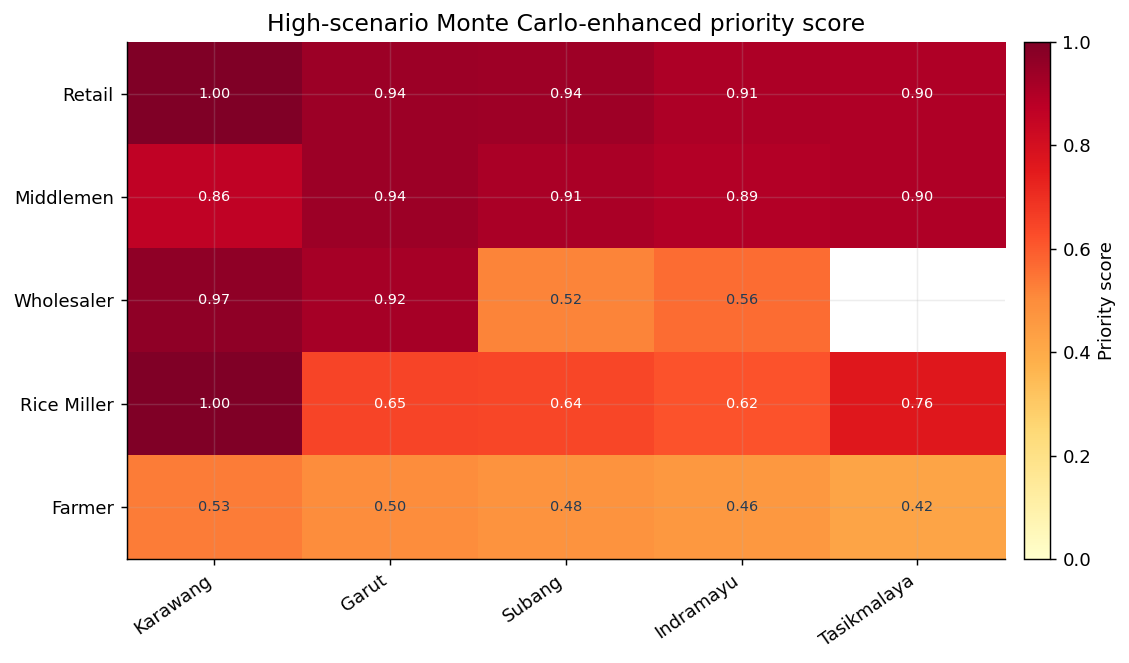

saved: figures\05_top10_monte_carlo_priority.png


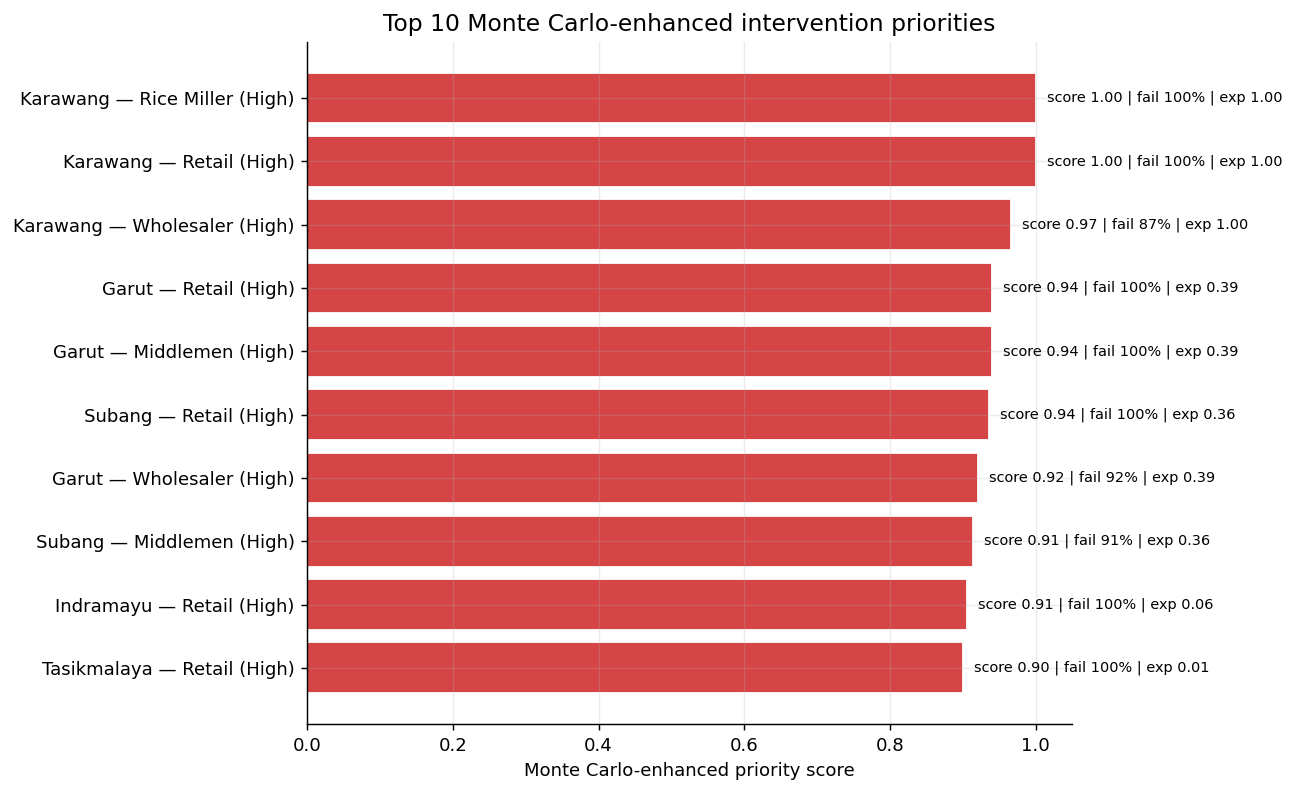

saved: figures\05_monte_carlo_top10_component_contribution.png


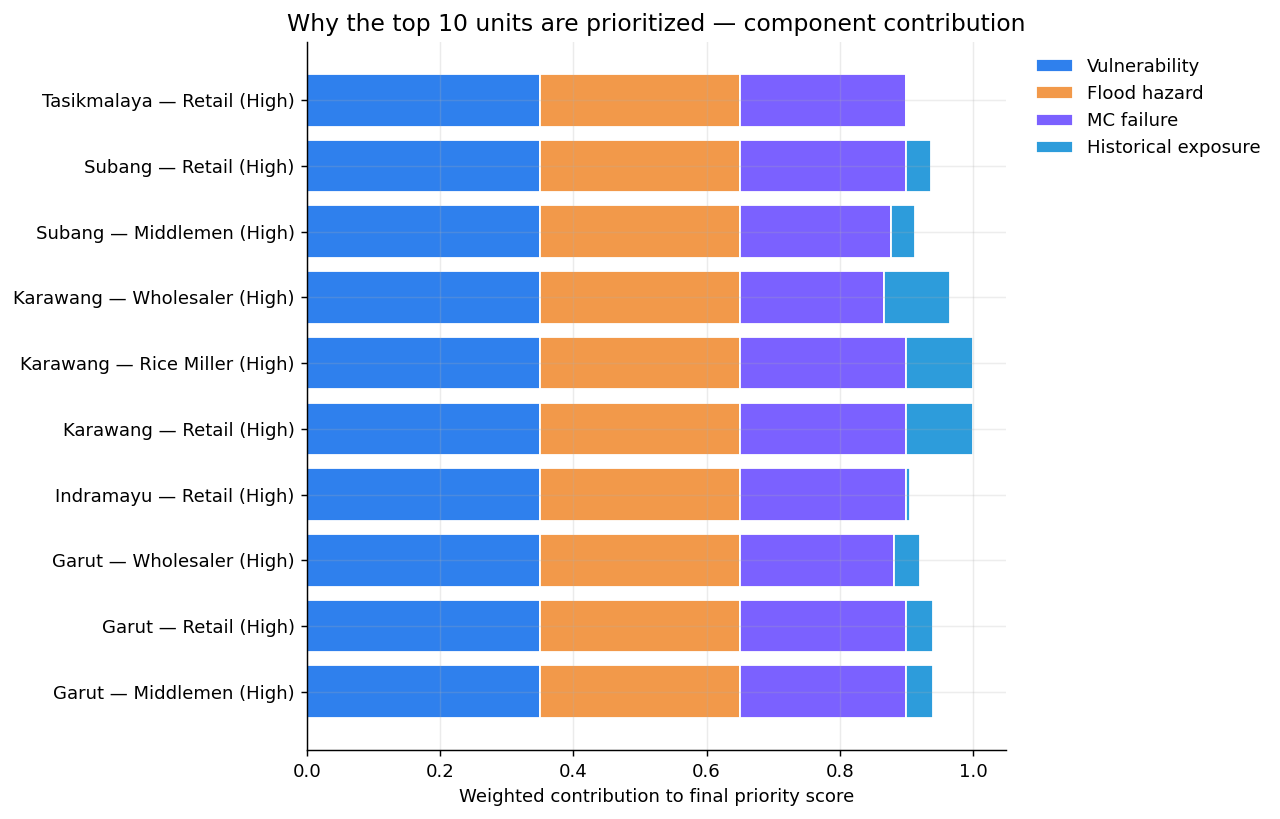

,figure,business_message
0,05_monte_carlo_priority_distribution.png,How intervention priority composition changes ...
1,05_monte_carlo_high_priority_heatmap.png,Which actor-region nodes are most critical und...
2,05_top10_monte_carlo_priority.png,Top final intervention priorities with MC fail...
3,05_monte_carlo_top10_component_contribution.png,Why the top 10 priorities were assigned: vulne...


In [48]:
# Monte Carlo-enhanced priority visualizations — focused final decision layer.

from matplotlib.ticker import PercentFormatter

scenario_order = ['Low', 'Medium', 'High']
priority_order = ['Low', 'Moderate', 'High', 'Critical']

# 1) Normalized priority composition by scenario.
counts = priority_mc.groupby(['flood_scenario', 'monte_carlo_enhanced_priority_label']).size().reset_index(name='count')
pivot = counts.pivot(index='flood_scenario', columns='monte_carlo_enhanced_priority_label', values='count').reindex(scenario_order).fillna(0)
pivot = pivot.reindex(columns=priority_order, fill_value=0)
share = pivot.div(pivot.sum(axis=1), axis=0).fillna(0)
share.to_csv(OUTPUT_DIR / '05_monte_carlo_priority_distribution_share.csv')

fig, ax = plt.subplots(figsize=(8.4, 4.8))
bottom = np.zeros(len(share))
priority_colors = {'Low': COLORS['green'], 'Moderate': COLORS['orange'], 'High': COLORS['purple'], 'Critical': COLORS['red']}
for col in priority_order:
    vals = share[col].values
    ax.bar(share.index, vals, bottom=bottom, label=col, color=priority_colors.get(col), edgecolor='white')
    for x, v, b in zip(range(len(vals)), vals, bottom):
        if v >= 0.08:
            ax.text(x, b + v/2, f'{v:.0%}', ha='center', va='center', fontsize=8, color='white')
    bottom += vals
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_ylim(0, 1.0)
ax.set_xlabel('Flood scenario')
ax.set_ylabel('Share of actor-region units')
ax.set_title('Monte Carlo-enhanced priority composition by scenario')
ax.legend(title='Priority', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.grid(axis='y', alpha=0.25)
savefig('05_monte_carlo_priority_distribution.png')
plt.show()

# 2) High-scenario priority heatmap: final score by actor-region.
high_priority = priority_mc[priority_mc['flood_scenario'].eq('High')].copy()
actor_order = (
    high_priority.groupby('actor')['monte_carlo_enhanced_priority_score'].mean()
    .sort_values(ascending=False).index.tolist()
)
region_order = (
    high_priority.groupby('region')['historical_flood_exposure_score'].median()
    .sort_values(ascending=False).index.tolist()
)
heat = high_priority.pivot_table(index='actor', columns='region', values='monte_carlo_enhanced_priority_score', aggfunc='mean')
heat = heat.reindex(index=actor_order, columns=region_order)
heat.to_csv(OUTPUT_DIR / '05_monte_carlo_high_priority_heatmap_values.csv')

fig, ax = plt.subplots(figsize=(8.8, 5.2))
im = ax.imshow(heat.values, aspect='auto', vmin=0, vmax=1, cmap='YlOrRd')
ax.set_xticks(np.arange(len(heat.columns)))
ax.set_yticks(np.arange(len(heat.index)))
ax.set_xticklabels(heat.columns, rotation=35, ha='right')
ax.set_yticklabels(heat.index)
ax.set_title('High-scenario Monte Carlo-enhanced priority score')
for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        val = heat.iloc[i, j]
        if pd.notna(val):
            ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=8,
                    color='white' if val >= 0.60 else '#243B53')
cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
cbar.set_label('Priority score')
savefig('05_monte_carlo_high_priority_heatmap.png')
plt.show()

# 3) Top 10 final intervention priorities with MC failure and external exposure annotations.
fig, ax = plt.subplots(figsize=(10, 6.2))
top10 = priority_mc.head(10).copy().sort_values('monte_carlo_enhanced_priority_score')
top10['actor_region'] = top10['region'] + ' — ' + top10['actor'] + ' (' + top10['flood_scenario'] + ')'
bars = ax.barh(top10['actor_region'], top10['monte_carlo_enhanced_priority_score'], color=COLORS['red'], edgecolor='white')
ax.set_xlim(0, 1.05)
ax.set_xlabel('Monte Carlo-enhanced priority score')
ax.set_title('Top 10 Monte Carlo-enhanced intervention priorities')
for b, score, fail, exp in zip(bars, top10['monte_carlo_enhanced_priority_score'], top10['mean_failure_probability'], top10['historical_flood_exposure_score']):
    ax.text(min(score + 0.015, 1.02), b.get_y() + b.get_height()/2,
            f'score {score:.2f} | fail {fail:.0%} | exp {exp:.2f}', va='center', fontsize=8)
ax.grid(axis='x', alpha=0.25)
savefig('05_top10_monte_carlo_priority.png')
plt.show()

# 4) Component contribution view for the top 10 priorities.
component_cols = ['vulnerability_component', 'hazard_component', 'monte_carlo_failure_component', 'external_exposure_component']
component_weights = {'vulnerability_component': 0.35, 'hazard_component': 0.30, 'monte_carlo_failure_component': 0.25, 'external_exposure_component': 0.10}
component_plot = priority_mc.head(10)[['region', 'actor', 'flood_scenario', *component_cols]].copy()
for col in component_cols:
    component_plot[col + '_weighted'] = component_plot[col] * component_weights[col]
component_plot['actor_region'] = component_plot['region'] + ' — ' + component_plot['actor'] + ' (' + component_plot['flood_scenario'] + ')'
component_plot = component_plot.sort_values('actor_region')
component_plot.to_csv(OUTPUT_DIR / '05_monte_carlo_top10_component_contribution.csv', index=False)

fig, ax = plt.subplots(figsize=(10, 6.4))
y = np.arange(len(component_plot))
left = np.zeros(len(component_plot))
labels = [
    ('vulnerability_component_weighted', 'Vulnerability'),
    ('hazard_component_weighted', 'Flood hazard'),
    ('monte_carlo_failure_component_weighted', 'MC failure'),
    ('external_exposure_component_weighted', 'Historical exposure')
]
colors = [COLORS['blue'], COLORS['orange'], COLORS['purple'], COLORS['teal']]
for (col, label), color in zip(labels, colors):
    vals = component_plot[col].values
    ax.barh(component_plot['actor_region'], vals, left=left, label=label, color=color, edgecolor='white')
    left += vals
ax.set_xlabel('Weighted contribution to final priority score')
ax.set_title('Why the top 10 units are prioritized — component contribution')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
ax.grid(axis='x', alpha=0.25)
savefig('05_monte_carlo_top10_component_contribution.png')
plt.show()

mc_visual_index = pd.DataFrame([
    {'figure': '05_monte_carlo_priority_distribution.png', 'business_message': 'How intervention priority composition changes across flood scenarios.'},
    {'figure': '05_monte_carlo_high_priority_heatmap.png', 'business_message': 'Which actor-region nodes are most critical under the high flood scenario.'},
    {'figure': '05_top10_monte_carlo_priority.png', 'business_message': 'Top final intervention priorities with MC failure probability and historical exposure.'},
    {'figure': '05_monte_carlo_top10_component_contribution.png', 'business_message': 'Why the top 10 priorities were assigned: vulnerability, hazard, failure, and exposure components.'},
])
mc_visual_index.to_csv(OUTPUT_DIR / '05_monte_carlo_visualization_index.csv', index=False)
display(mc_visual_index)